## Задание 1. Реализация градиентного спуска (3.5 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`.

**Все реализуемые методы должны быть векторизованы!**

### Задание 1.1. Родительский класс BaseDescent (0.5 балла).

Реализуйте функции `calc_loss` (вычисление MSE для переданных $x$ и $y$) и `predict` (предсказание $y_{pred}$ для переданных $x$) в классе `BaseDescent`.

Все вычисления должны быть векторизованы.

### Задание 1.2. Полный градиентный спуск VanillaGradientDescent (0.5 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Для вычисления градиента используйте формулу выше. Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь и далее функция `update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса.

Во всех методах градиентного спуска мы будем использовать следующую формулу для длины шага:

$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

### Лирическое-теоретическое отступление № 3

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

В нашем домашнем задании отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (будем его называть полным градиентом):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов.

В этом случае мы получим метод **стохастического градиентного спуска**.

### Задание 1.3. Стохастический градиентный спуск StochasticDescent (0.5 балла).

Реализуйте стохастический градиентный спуск заполнив пропуски в классе `StochasticDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться гиперпараметром метода, семплируйте индексы для батча объектов с помощью `np.random.randint`.

### Лирическое-теоретическое отступление № 4

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Введём для этого вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация. Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### Задание 1.4 Метод Momentum MomentumDescent (0.5 балла).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ будет являться гиперпараметром метода, но в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

### Лирическое-теоретическое отступление № 5

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров. При этом шаг будет тем меньше, чем более длинные шаги мы делали на предыдущих итерациях:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения **(обратите внимание, что в данном домашнем задании длина шага не фиксируется)**. Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций и делать адаптивную длину шага по каждому параметру.

### Задание 1.5. Метод Adam (Adaptive Moment Estimation) (1.5 балла).

Реализуйте градиентный спуск с методом Adam заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

## Задание 2. Реализация линейной регресии (0.5 балла)

В этом задании вам предстоит написать свою реализацию линейной регресии, обучаемой с использованием градиентного спуска, с опорой на подготовленные шаблоны в файле `linear_regression.py` - **LinearRegression**. По сути линейная регрессия будет оберткой, которая запускает обучение

Необходимо соблюдать следующие условия:

* Все вычисления должны быть векторизованы;
* Циклы средствами python допускаются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Будем считать, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели надо обновлять внутри функции `update_weights`, она неспроста так называется
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `loss_history`, в нём будем хранить значения функции потерь до каждого шага, начиная с нулевого (до первого шага по антиградиенту) и значение функции потерь после оптимизации.

## Задание 3. Проверка кода (0 баллов)

In [ ]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%autoreload 2

import numpy as np

from descents import get_descent
from linear_regression import LinearRegression

In [ ]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [ ]:
# Descents

descent_config = {
    'descent_name': 'some name that we will replace in the future',
    'kwargs': {
        'dimension': dimension
    }
}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    descent_config['descent_name'] = descent_name
    descent = get_descent(descent_config)

    diff = descent.step(x, y)
    gradient = descent.calc_gradient(x, y)
    predictions = descent.predict(x)

    assert gradient.shape[0] == dimension, f'Gradient failed for descent {descent_name}'
    assert diff.shape[0] == dimension, f'Weights failed for descent {descent_name}'
    assert predictions.shape == y.shape, f'Prediction failed for descent {descent_name}'

In [ ]:
# LinearRegression

max_iter = 10
tolerance = 0

descent_config = {
    'descent_name': 'stochastic',
    'kwargs': {
        'dimension': dimension,
        'batch_size': 10
    }
}

regression = LinearRegression(
    descent_config=descent_config,
    tolerance=tolerance,
    max_iter=max_iter
)

regression.fit(x, y)

assert len(regression.loss_history) == max_iter + 1, 'Loss history failed'

Если ваше решение прошло все тесты локально, то теперь пришло время протестировать его в [Яндекс Контесте](https://contest.yandex.ru/contest/54610/).

Для каждой задачи из контеста вставьте ссылку на успешную посылку:

* **VanillaGradientDescent**: https://contest.yandex.ru/contest/70588/run-report/124775490/


* **StochasticDescent**: https://contest.yandex.ru/contest/70588/run-report/124773041/


* **MomentumDescent**: https://contest.yandex.ru/contest/70588/run-report/124775624/

* **Adam**: https://contest.yandex.ru/contest/70588/run-report/124775640/


* **LinearRegression**: https://contest.yandex.ru/contest/70588/run-report/124775451/

## Задание 4. Работа с данными (1 балл)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

* Постройте график распределения целевой переменной в данных, подумайте, нужно ли заменить её на логарифм. Присутствуют ли выбросы в данных с аномальной ценой? Если да, то удалите их из данных.

* Проведите исследование данных:
    * Проанализируйте тип столбцов, постройте графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;
    * Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;
    * Разделите полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделите данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [ ]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from descents import get_descent
from linear_regression import LinearRegression

sns.set(style='darkgrid')

In [ ]:
! wget https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2024-fall/homework-practice/homework-practice-03-gd/autos.csv

--2024-11-13 16:20:32--  https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2024-fall/homework-practice/homework-practice-03-gd/autos.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14767172 (14M) [text/plain]
Saving to: ‘autos.csv’

autos.csv           100%[===================>]  14.08M  --.-KB/s    in 0.1s    

2024-11-13 16:20:32 (115 MB/s) - ‘autos.csv’ saved [14767172/14767172]



In [ ]:
data = pd.read_csv('autos.csv')  # разумеется, если вы используете не pandas, это надо поменять

In [ ]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

In [ ]:
data.isna().sum() # нет пропусков

,0
brand,0
model,0
vehicleType,0
gearbox,0
fuelType,0
notRepairedDamage,0
powerPS,0
kilometer,0
autoAgeMonths,0
price,0


In [ ]:
data.duplicated().sum() # в датасете есть дубликаты, удалим их

18903

In [ ]:
data.drop_duplicates(inplace=True)

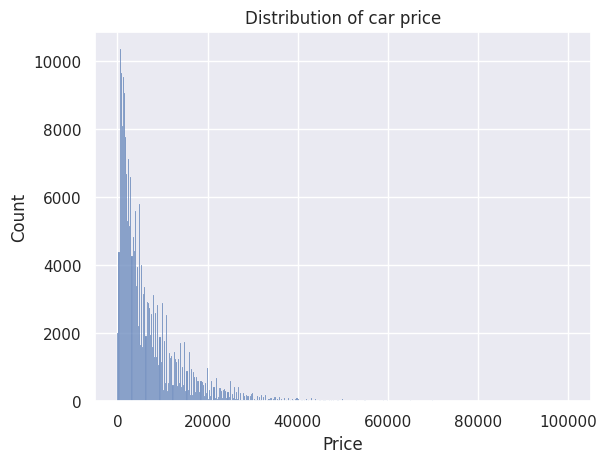

In [ ]:
# распределение целевой переменной
sns.histplot(data['price'])
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of car price');

Как я поняла, здесь цены в долларах или евро. Из гистограммы видно, что это скошенное вправо распределение, есть тяжелый хвост справа. При этом не видно, какие вообще значения в левой части (возможно, есть машины по 1 доллару или еще чего). Прологарифмируем и посмотрим, что будет.

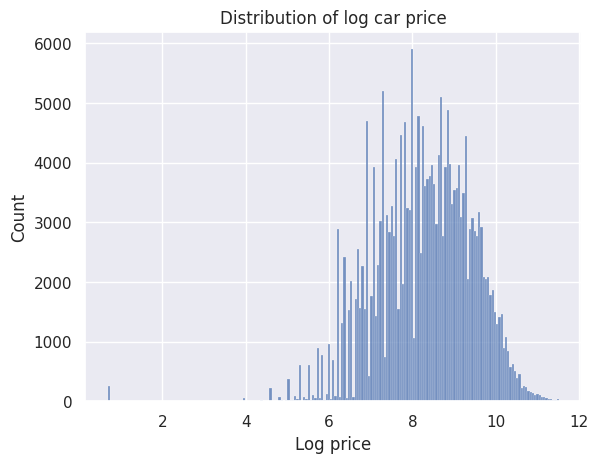

In [ ]:
sns.histplot(np.log1p(data['price']))
plt.xlabel('Log price')
plt.ylabel('Count')
plt.title('Distribution of log car price');

Видно, что есть выбросы как слева, так и справа, удалим их с помощью интерквартильного размаха.

In [ ]:
q1 = np.log1p(data['price']).quantile(0.25)
q3 = np.log1p(data['price']).quantile(0.75)
iqr = q3 - q1

lim_up = q3 + 1.5 * iqr
lim_low = q1 - 1.5 * iqr
lim_up, lim_low

(11.560536142367114, 5.012386046237095)

In [ ]:
outliers = (np.log1p(data['price']) > lim_up) | (np.log1p(data['price']) < lim_low)
data.drop(data[outliers].index, inplace=True)

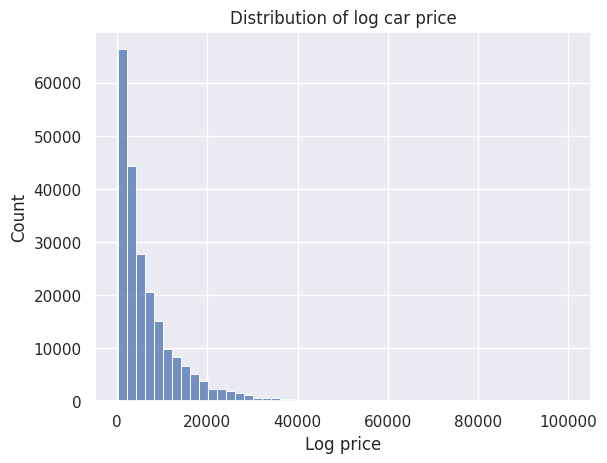

In [ ]:
sns.histplot(data['price'], bins=50)
plt.xlabel('Log price')
plt.ylabel('Count')
plt.title('Distribution of log car price');

У цены все еще есть выбросы (значения до 100000). Удалим экстремальные значения (отклюняющиеся на 3 интерквартильного размаха)

In [ ]:
q1 = data['price'].quantile(0.25)
q3 = data['price'].quantile(0.75)
iqr = q3 - q1

lim_up = q3 + 3 * iqr
outliers = data['price'] > lim_up
data.drop(data[outliers].index, inplace=True)

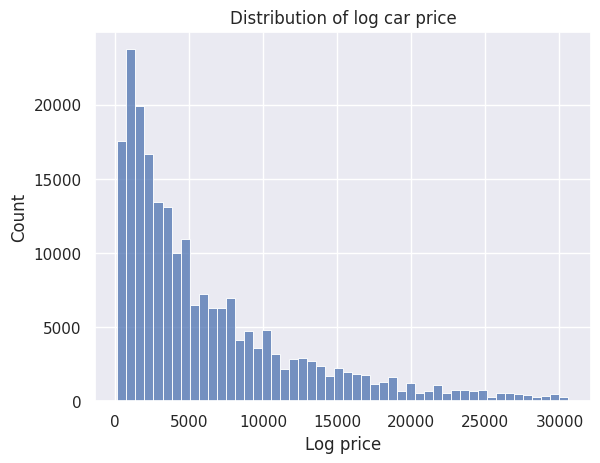

In [ ]:
sns.histplot(data['price'], bins=50)
plt.xlabel('Log price')
plt.ylabel('Count')
plt.title('Distribution of log car price');

Стало получше. Буду предсказывать саму цену, а не логарифм, потому что в целом распределение хорошее после избавления от выбросов.

Далее перейдем к признакам.
Начнем с количественных: мощность, пробег, возраст. Это количественные, так как их можно сравнить между собой, посчитать разницу; они выражаются численно.
Остальные - качественные, так как они обозначают категории, качества объектов, не могут быть сравнимы (по какой-то единой шкале). Бинарные я тоже отношу к качественным признакам.

In [ ]:
data.dtypes

,0
brand,object
model,object
vehicleType,object
gearbox,object
fuelType,object
notRepairedDamage,object
powerPS,int64
kilometer,int64
autoAgeMonths,int64
price,int64


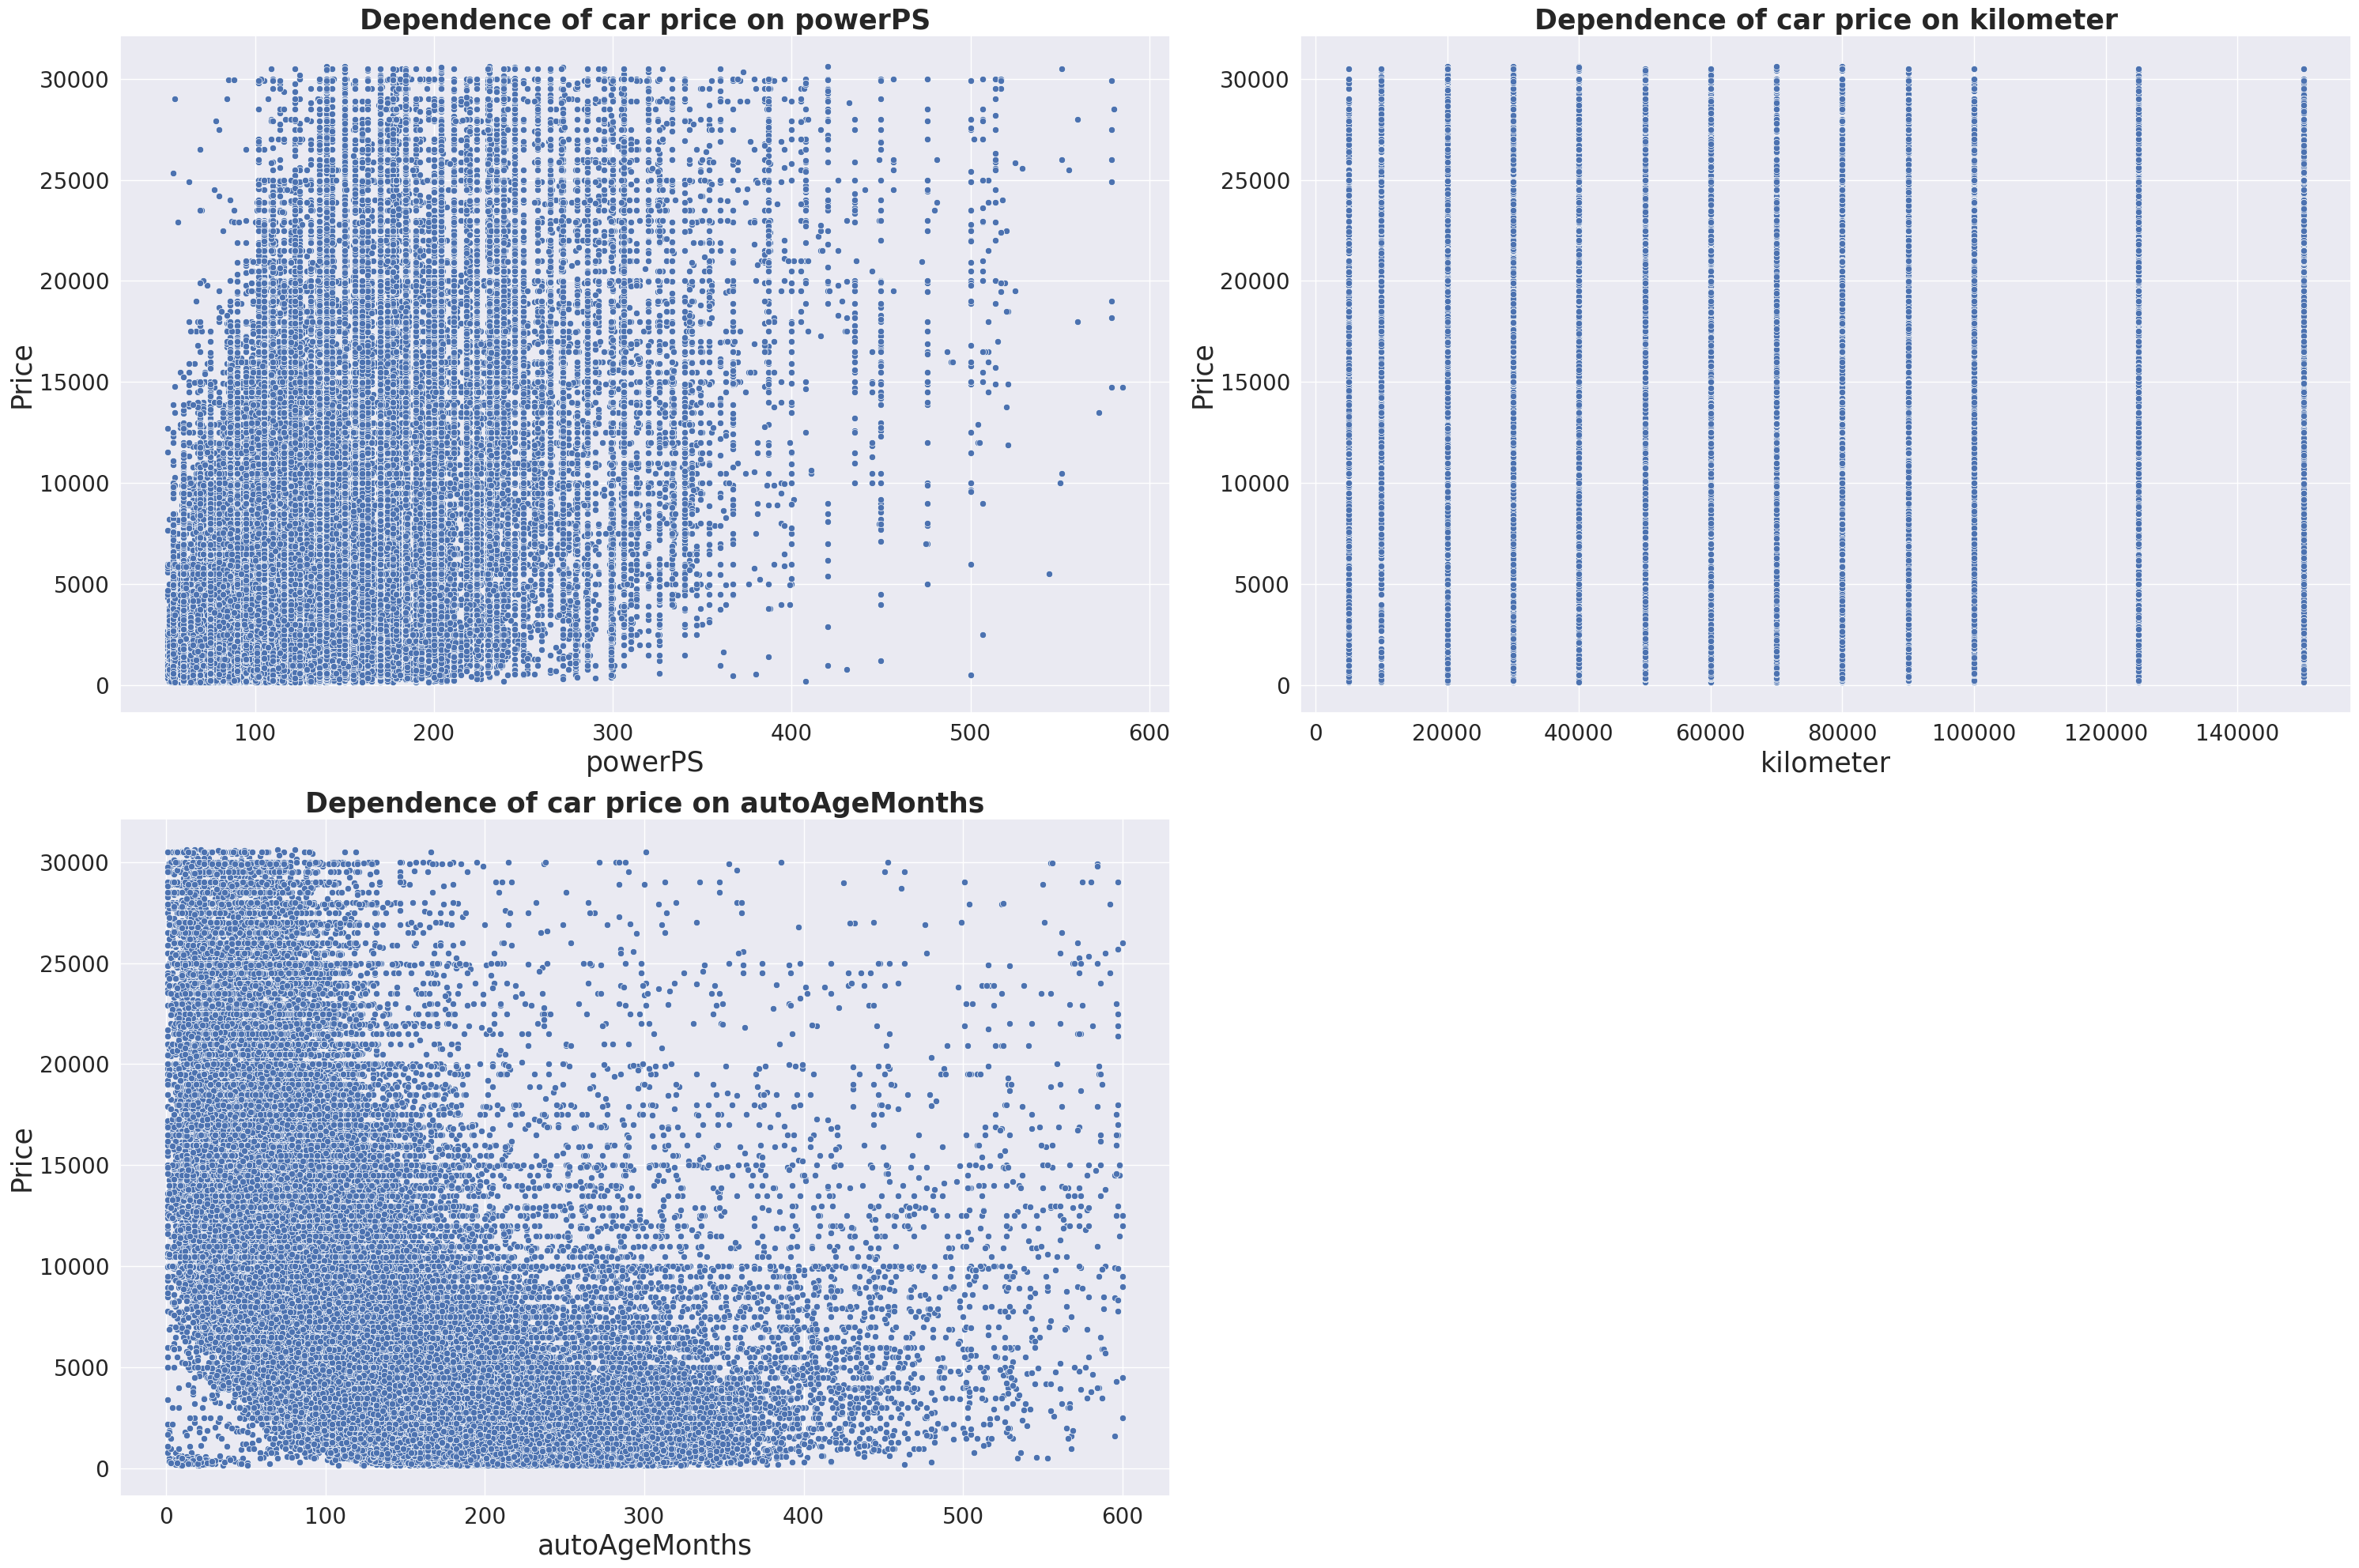

In [ ]:
from matplotlib import gridspec
import itertools

fig = plt.figure(figsize = (30, 20))
gr = gridspec.GridSpec(2, 2)
features = ['powerPS', 'kilometer', 'autoAgeMonths']
for feature, grd in zip(features, itertools.product([0, 1], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.scatterplot(data=data, x=feature, y='price')
    ax.tick_params(labelsize=20)
    ax.set_title(f'Dependence of car price on {feature}', fontsize = 25, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 25)
    ax.set_ylabel('Price', fontsize = 25)
fig.tight_layout()
plt.show()

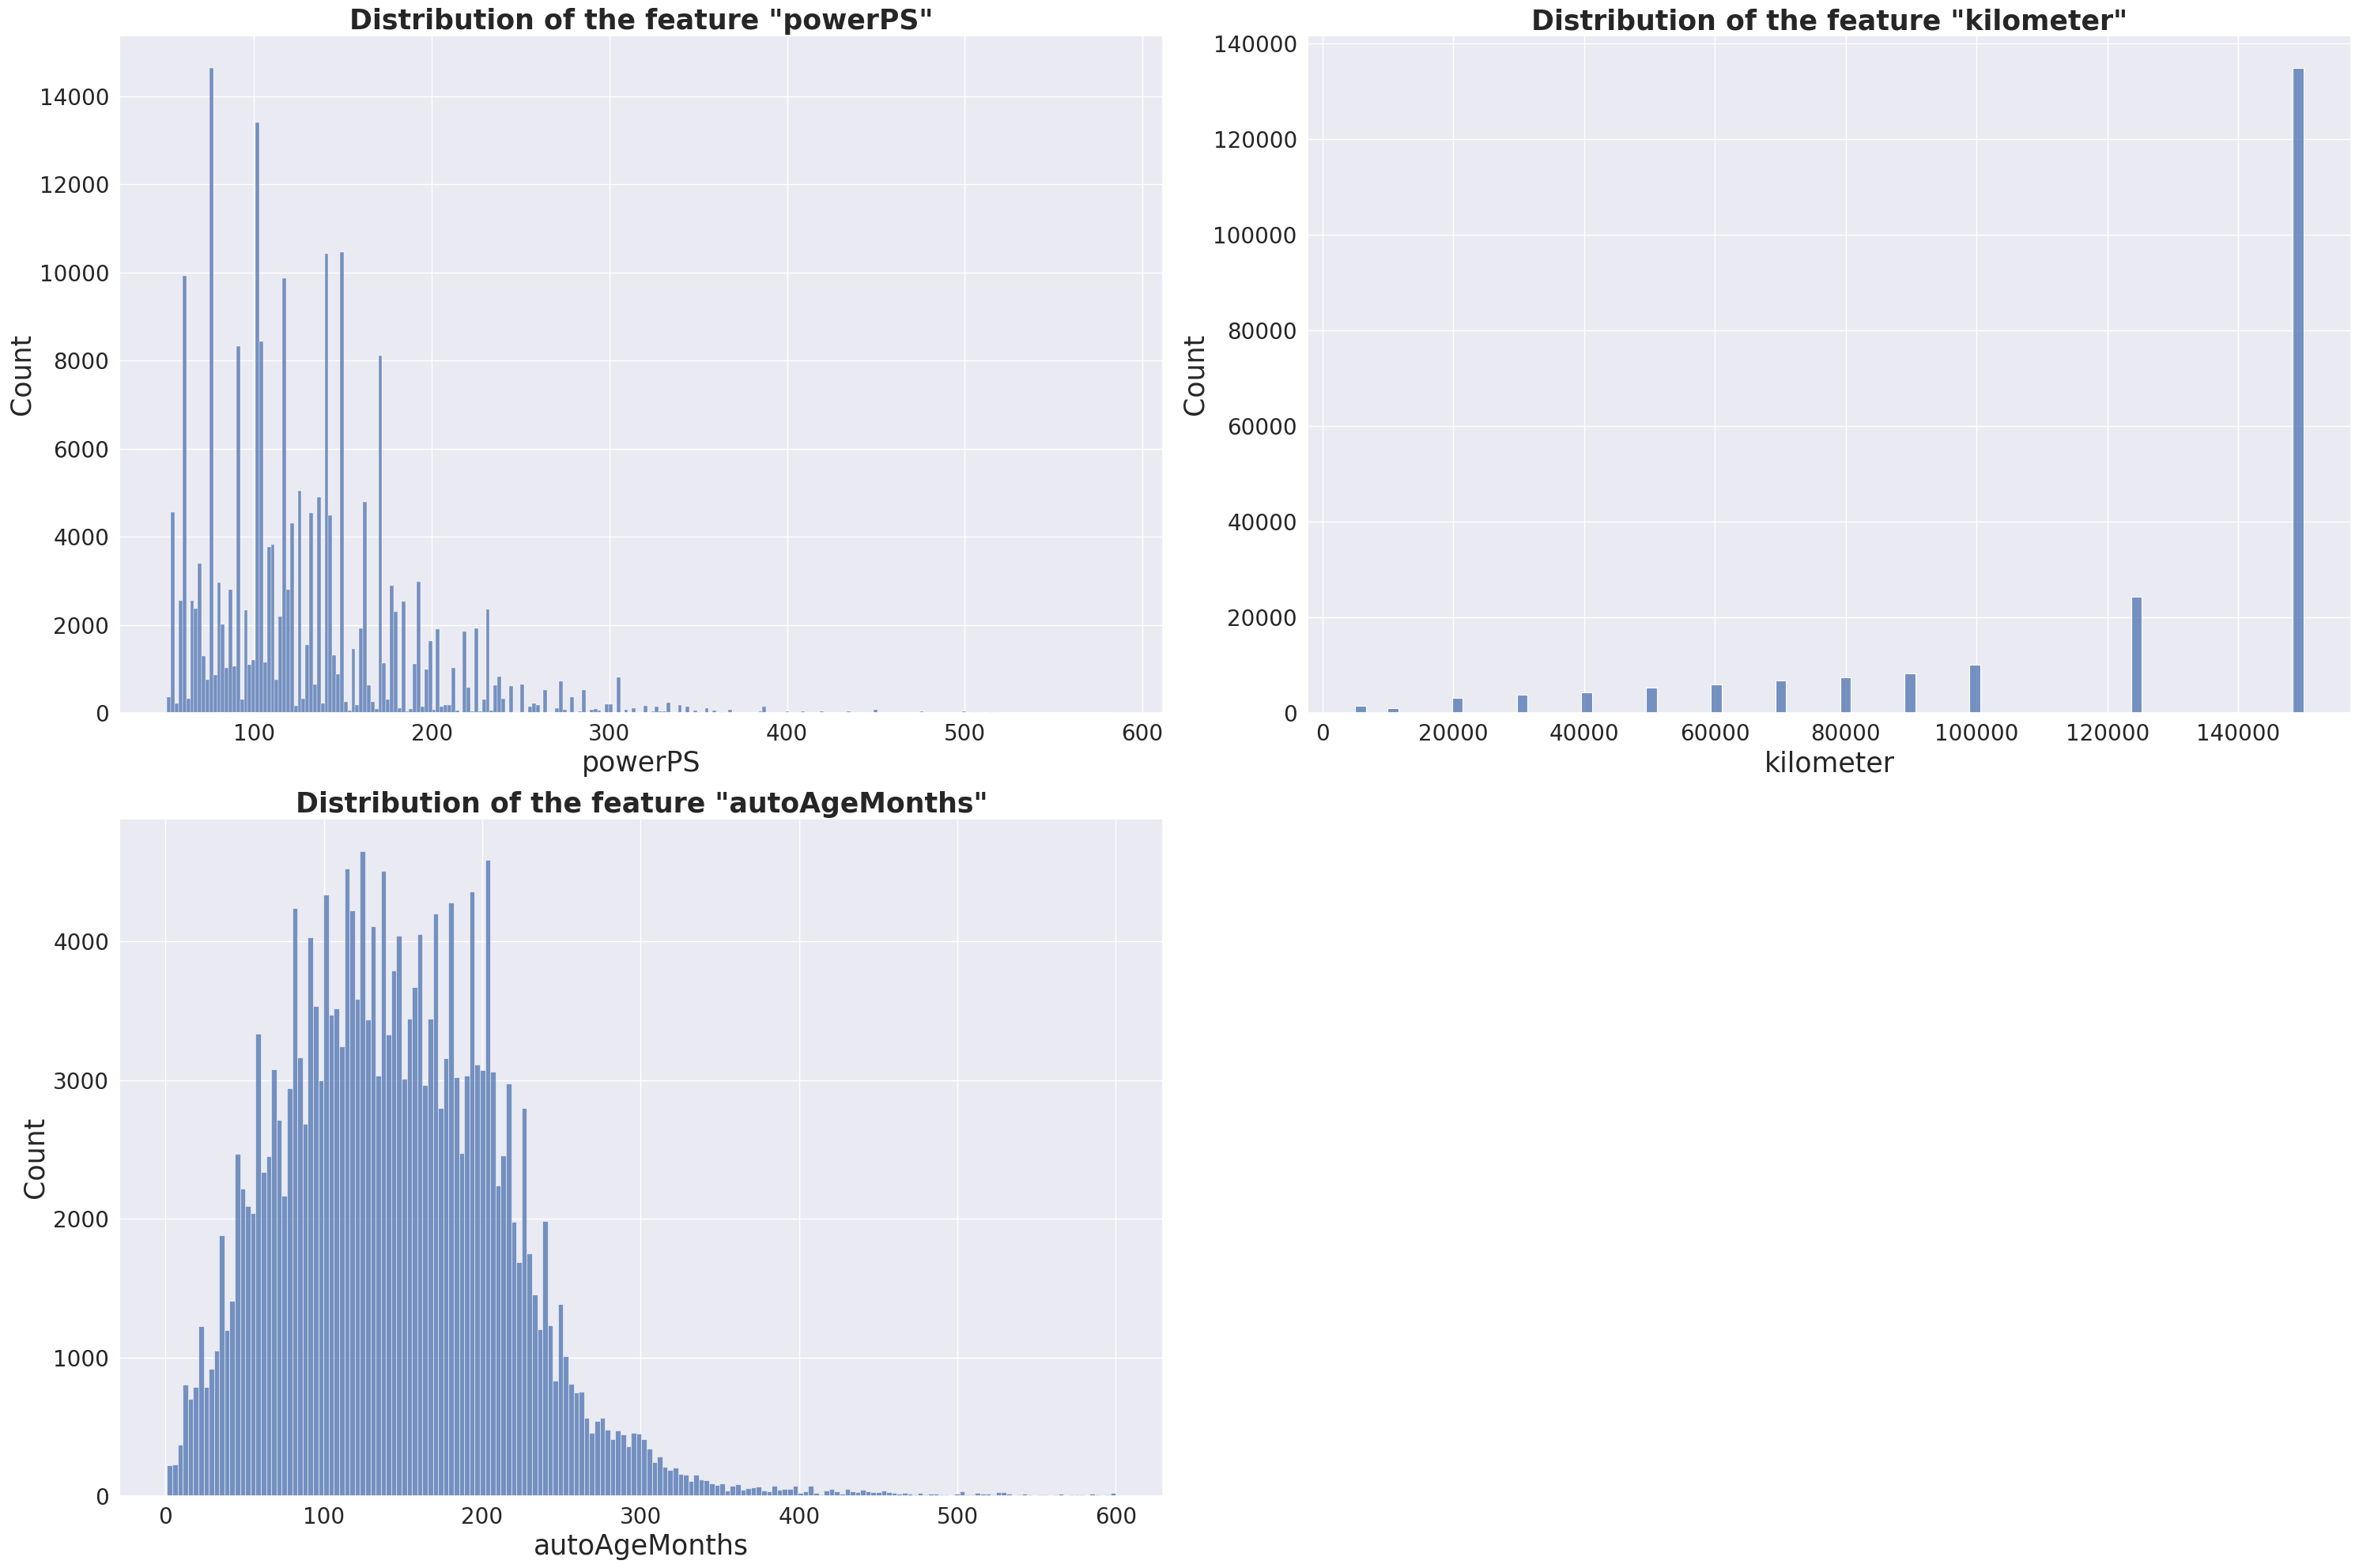

In [ ]:
fig = plt.figure(figsize = (30, 20))
gr = gridspec.GridSpec(2, 2)
features = ['powerPS', 'kilometer', 'autoAgeMonths']
for feature, grd in zip(features, itertools.product([0, 1], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.histplot(data[feature])
    ax.tick_params(labelsize=20)
    ax.set_title(f'Distribution of the feature "{feature}"', fontsize = 25, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 25)
    ax.set_ylabel('Count', fontsize = 25)
fig.tight_layout()
plt.show()

In [ ]:
data.describe()

,powerPS,kilometer,autoAgeMonths,price
count,217144.000000,217144.000000,217144.000000,217144.000000
mean,128.734821,124868.082931,146.299000,6225.724574
std,56.380279,38836.382201,72.052873,6093.346248
min,51.000000,5000.000000,1.000000,150.000000
25%,90.000000,100000.000000,94.000000,1750.000000
50%,116.000000,150000.000000,141.000000,3999.000000
75%,155.000000,150000.000000,193.000000,8650.000000
max,585.000000,150000.000000,600.000000,30600.000000


По точечным графикам можно наблюдать положительную зависимость между мощностью автомобиля и логарифмом цены, отрицательную между возрастом автомобиля и логарифмом цены (изменение объясняющей переменной на 1 приводит к изменению (увеличению/снижению) зависимой на примерно w * 100%), однако есть много точек (возможно выбросы), которые не попадают под общий тренд. Зависимость логарифма цены от пробега судя по графику не отслеживается.

По гистограммам распределения признаков видно, что есть сильно выделяющиеся наблюдения (возможные выбросы). По описательным характеристикам нет каких-то аномалий/возможных ошибок (типа мощность 0 л.с.), но есть не вписывающиеся в основную массу наблюдения (возраст автомобиля 50 лет это уже какой-то антиквариат, а 589 л.с. - молния маккуин). Чтобы повысить обобщающую способность модели, их нужно удалить.

In [ ]:
data.shape

(217144, 10)

In [ ]:
# удаляем экстремальные наблюденияю, которые отклоняются на 3 iqr
for feature in ['powerPS', 'kilometer', 'autoAgeMonths']:
    q1 = data[feature].quantile(0.25)
    q3 = data[feature].quantile(0.75)
    iqr = q3 - q1
    lim_up = q3 + 3 * iqr
    lim_low = q1 - 3 * iqr
    outl = (data[feature] < lim_low) | (data[feature] > lim_up)
    data.drop(data[outl].index, inplace=True)

In [ ]:
data.shape

(215634, 10)

Перейдем к качественным признакам.

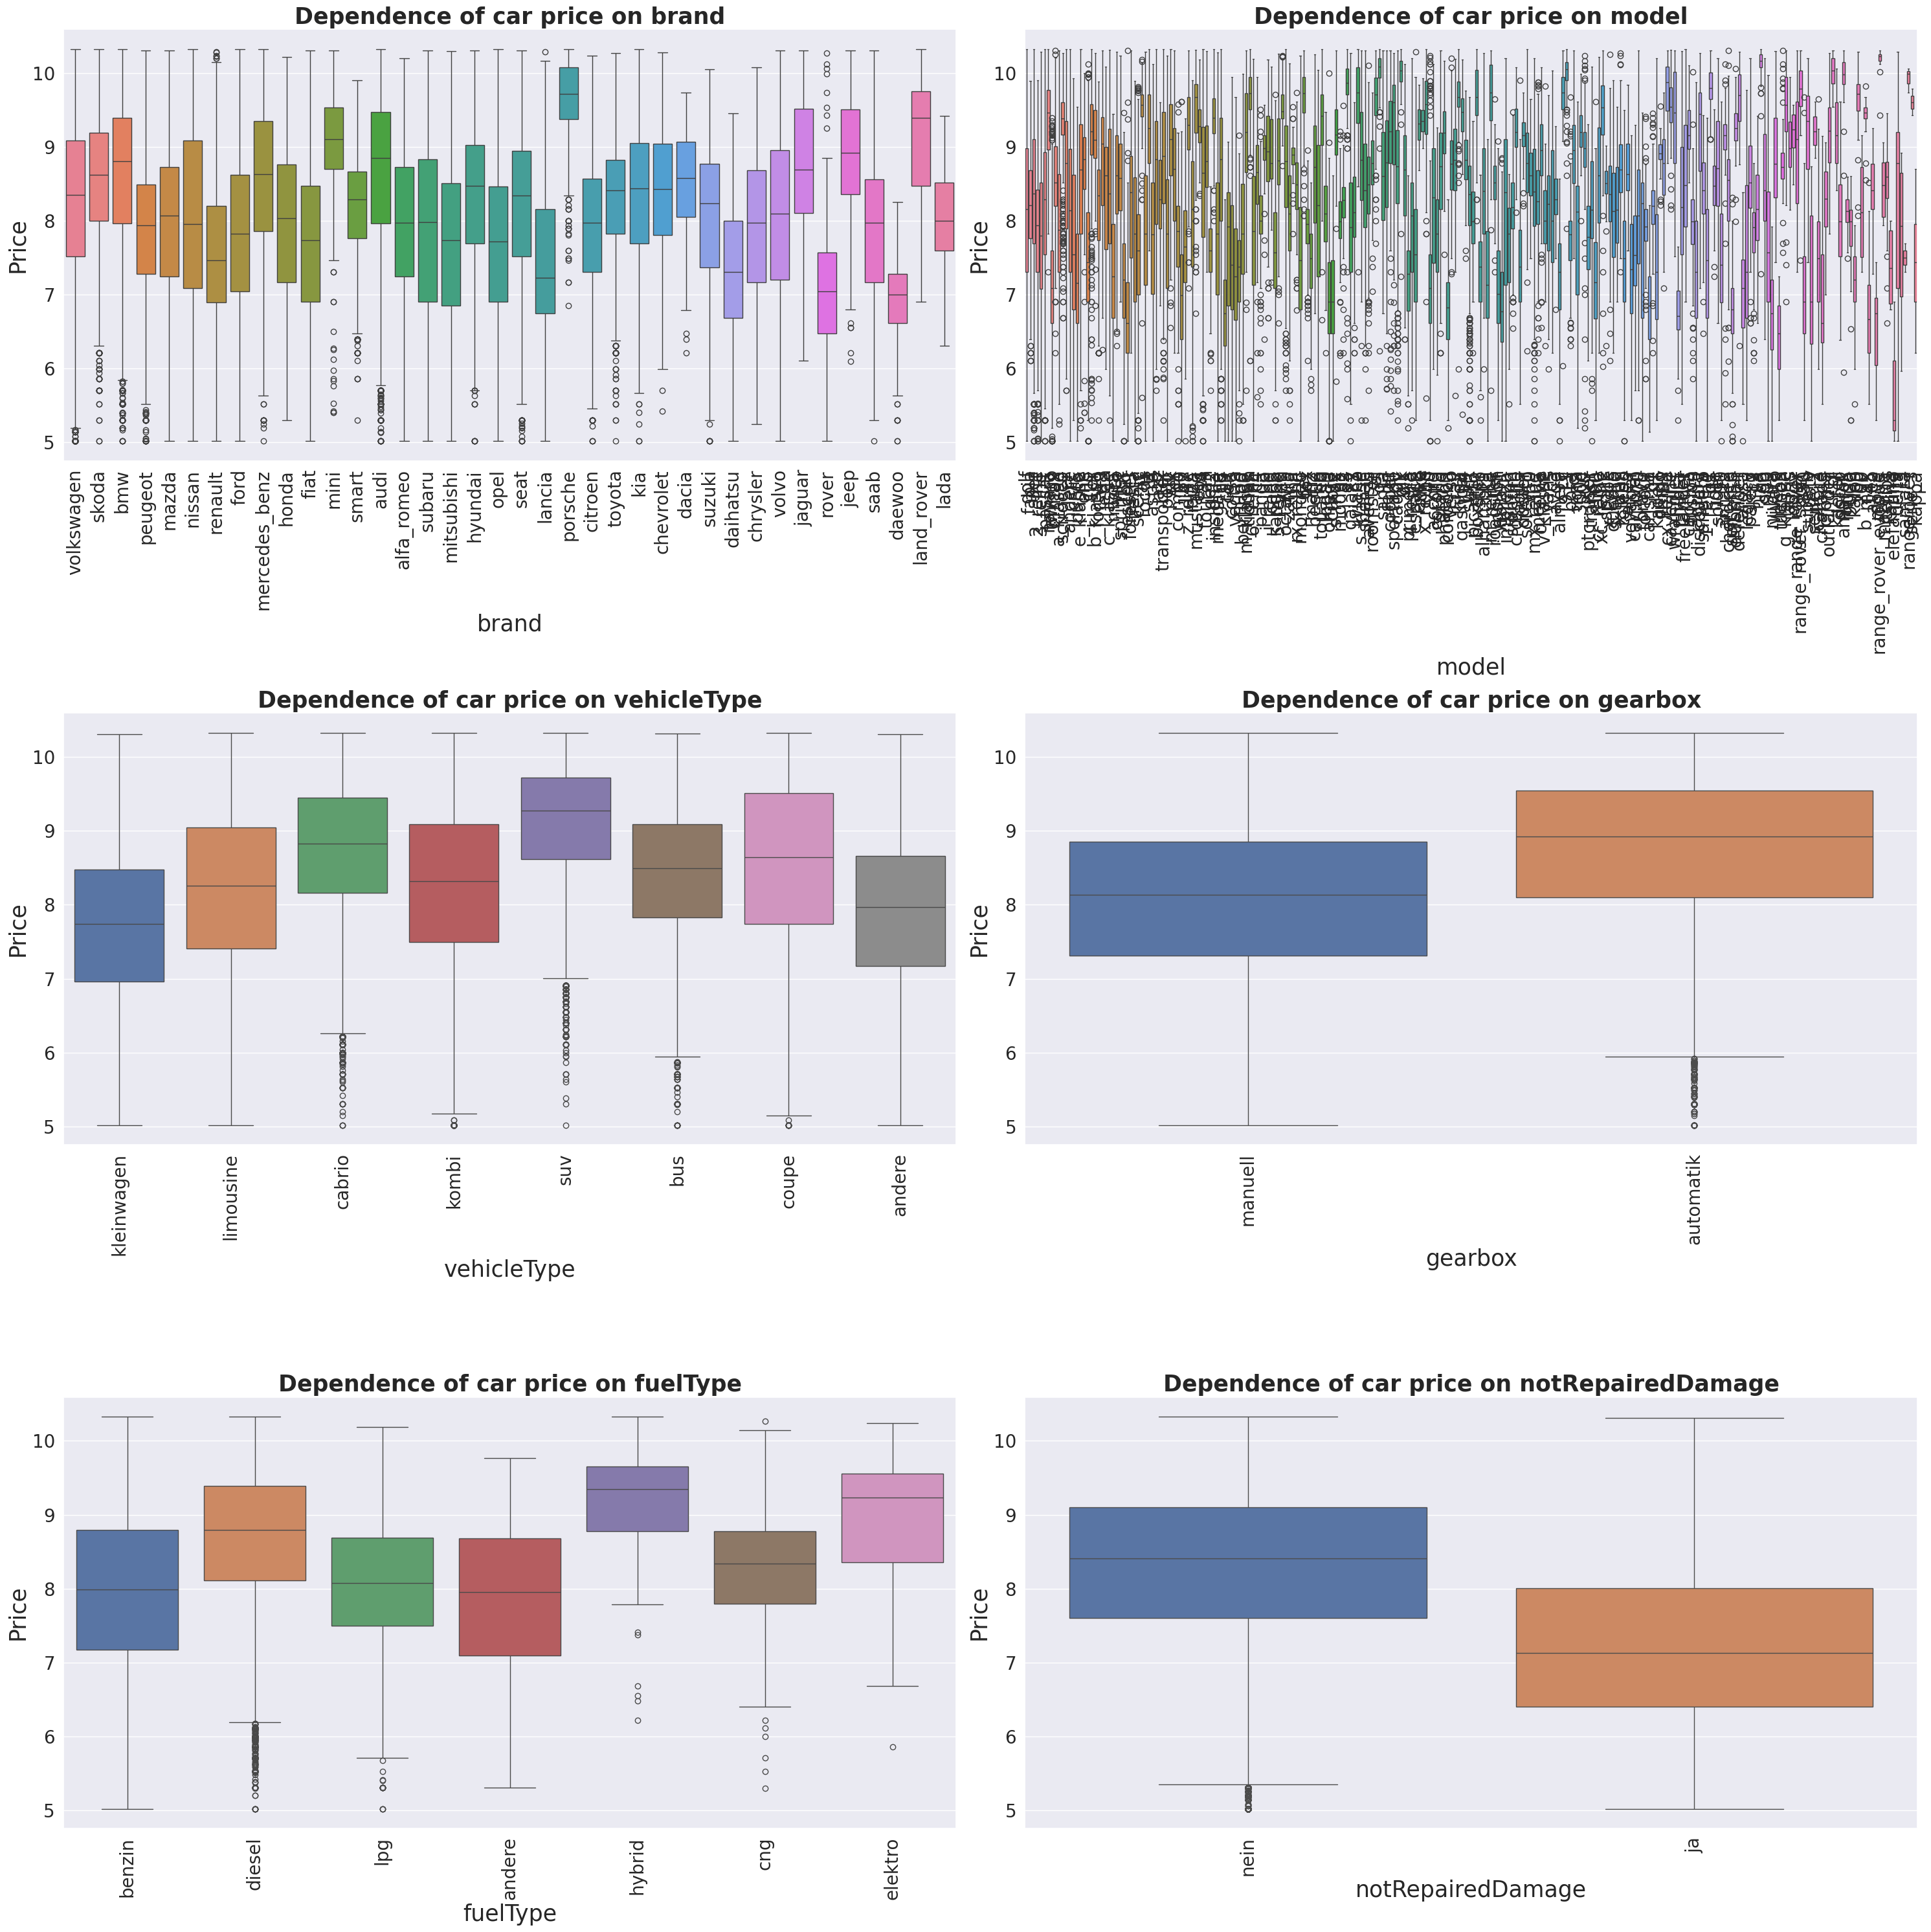

In [ ]:
fig = plt.figure(figsize = (30, 30))
gr = gridspec.GridSpec(3, 2)
features = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.boxplot(data=data, x=feature, y=np.log1p(data['price']), hue=feature)
    ax.tick_params(labelsize=20)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_title(f'Dependence of car price on {feature}', fontsize = 25, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 25)
    ax.set_ylabel('Price', fontsize = 25)
fig.tight_layout()
plt.show()

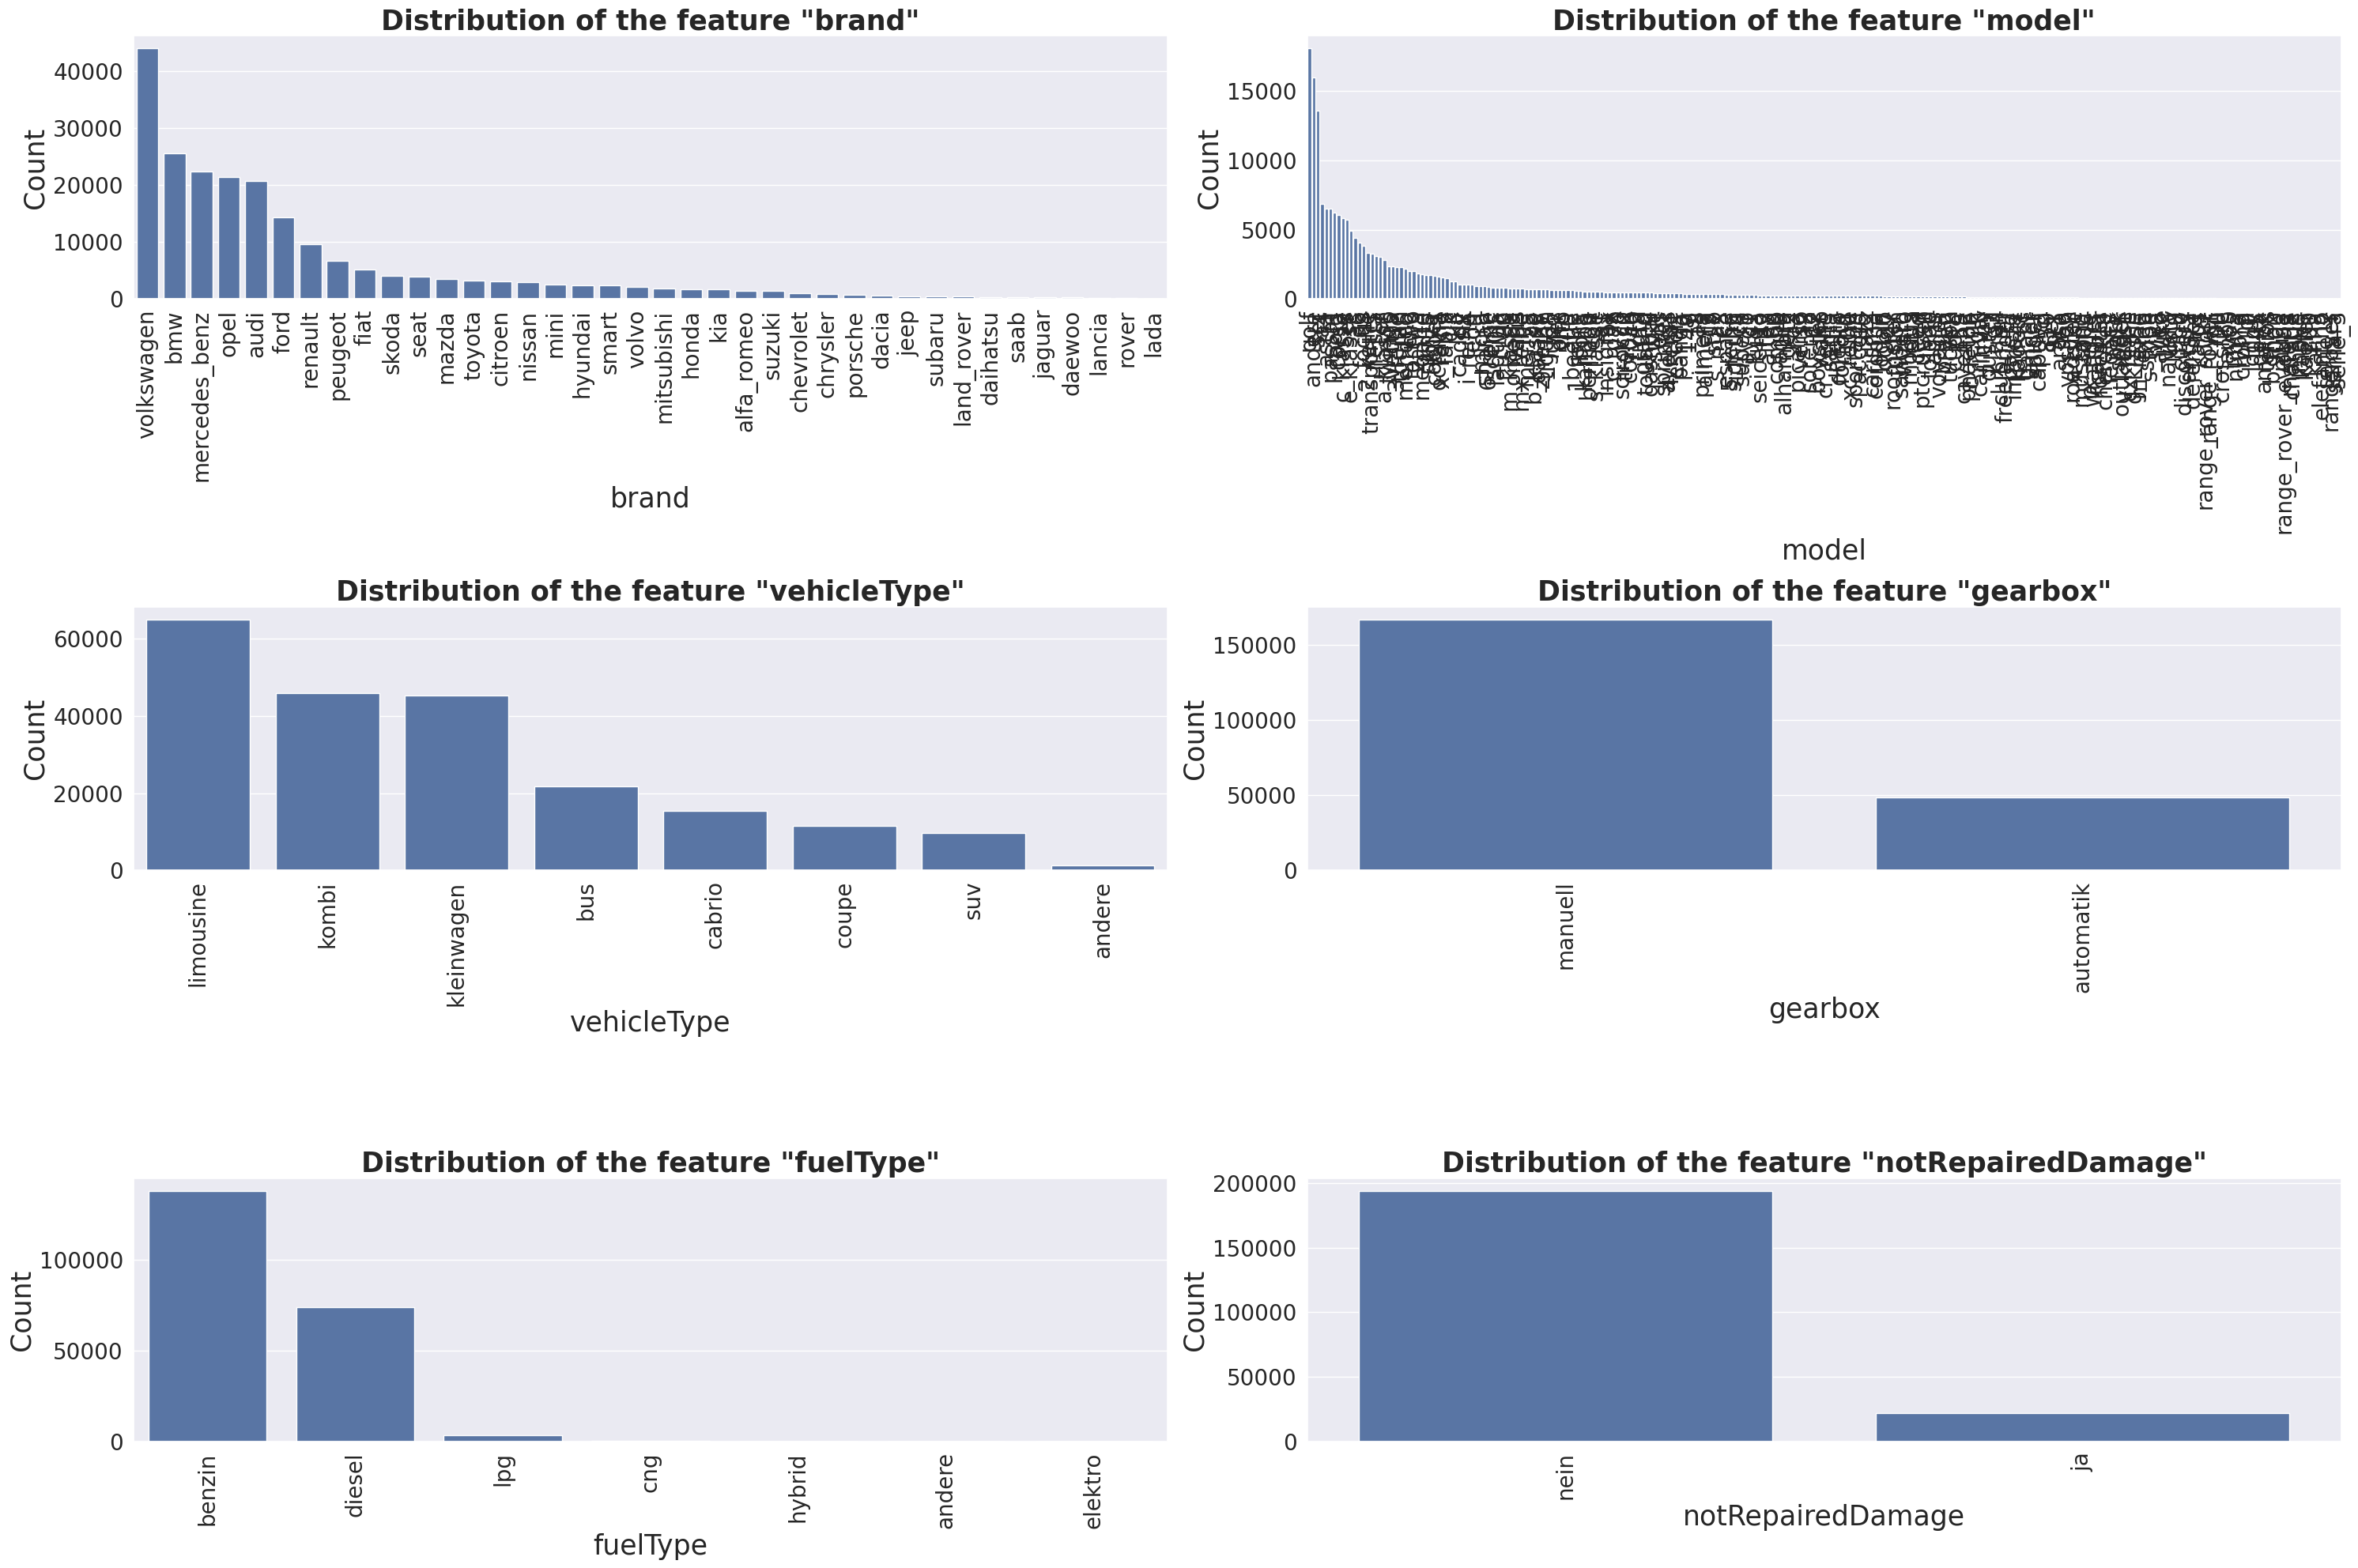

In [ ]:
fig = plt.figure(figsize = (30, 20))
gr = gridspec.GridSpec(3, 2)
features = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
for feature, grd in zip(features, itertools.product([0, 1, 2], [0, 1])):
    ax = plt.subplot(gr[grd[0], grd[1]])
    ax = sns.barplot(data[feature].value_counts())
    ax.tick_params(labelsize=20)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_title(f'Distribution of the feature "{feature}"', fontsize = 25, fontweight='heavy')
    ax.set_xlabel(feature, fontsize = 25)
    ax.set_ylabel('Count', fontsize = 25)
fig.tight_layout()
plt.show()

С признаком `model` разберемся далее (по графикам тяжело определить хоть что-нибудь, не смотрите на них...), посмотрим пока что на другие. В целом, по каждой категории признаков распределение цены не одинаково, поэтому все признаки могут быть полезны для определения целевой переменной.

Гистограммы показывают, что очень много категорий, в которых мало значений, их можно объединить или выбросить. Объединять я не буду, так как маленькие по численности группы различаются влиянием на цену (на модели может плохо сказаться если в одну группу попадут, например, порш и лада).

In [ ]:
# бренд: удаляем категории, где менее наблюдений меньше, чем квантиль 0.25
print(f'Таких категорий {(data["brand"].value_counts() < data["brand"].value_counts().quantile(0.25)).sum()}, всего категорий {data["brand"].nunique()}')
data['brand'].value_counts()

Таких категорий 10, всего категорий 38


,count
brand,
volkswagen,43996
bmw,25579
mercedes_benz,22369
opel,21478
audi,20769
ford,14333
renault,9623
peugeot,6653
fiat,5174


In [ ]:
outl_brand = data['brand'].value_counts()[data['brand'].value_counts() < data["brand"].value_counts().quantile(0.25)].index
data.drop(data[data['brand'].isin(outl_brand)].index, inplace=True)

In [ ]:
# vehicleType меньше всего наблюдений у категории "другой" (andere)
# но в целом 1242 достаточно, тем более, что это объединение других категорий
data['vehicleType'].value_counts()

,count
vehicleType,
limousine,64069
kombi,45405
kleinwagen,44671
bus,21577
cabrio,15233
coupe,11332
suv,8572
andere,1358


In [ ]:
# удалим 4 наименьшие по численности группы
data['fuelType'].value_counts()

,count
fuelType,
benzin,135288
diesel,73072
lpg,3221
cng,404
hybrid,177
andere,28
elektro,27


In [ ]:
data.drop(data[data['fuelType'].isin(data['fuelType'].value_counts()[3:].index)].index, inplace=True)

In [ ]:
# model: очень много категорий, где наблюдений лишь сотни
# удалю категории, в которых наблюдений меньше чем квантиль 0.25
print(f'Количество категорий: {data["model"].nunique()}')
print(f'Количество категорий, где наблюдений больше 200: {(data["model"].value_counts() > data["model"].value_counts().quantile(0.25)).sum()}')

Количество категорий: 211
Количество категорий, где наблюдений больше 200: 158


In [ ]:
outl_model = data['model'].value_counts()[data['model'].value_counts() < 200].index
data.drop(data[data['model'].isin(outl_model)].index, inplace=True)

Признаки с двумя значениями не трогаю, тк наблюдений каждой категории не критически мало + хорошее распределение цены.

In [ ]:
categorical = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = []

In [ ]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['price'].reset_index(drop=True)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])

x = column_transformer.fit_transform(x)

In [ ]:
X = pd.DataFrame(x.toarray(), columns=column_transformer.get_feature_names_out())

In [ ]:
from sklearn.model_selection import train_test_split
X_train1, X_test, y_train1, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train1, y_train1, test_size=0.1, random_state=42)

## Задание 5. Сравнение методов градиентного спуска (2 балла)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (1 балл)

Подберите по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделайте перебор по логарифмической сетке. Для каждого метода посчитайте ошибку на обучающей и тестовой выборках, посчитайте качество по метрике $R^2$, сохраните количество итераций до сходимости.

Все параметры кроме `lambda_` стоит выставить равным значениям по умолчанию.

In [ ]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

In [ ]:
np.random.seed(6)
descent_config = {
    'descent_name': '',
    'kwargs': {
        'dimension': X_train.shape[1],
        'lambda_': 0
    }
}

lambdas = np.logspace(-3, 0.5, 10)
best_lambdas = []

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    descent_config['descent_name'] = descent_name
    loss_val = np.array([])
    loss_train = np.array([])
    for lambda_ in lambdas:
        descent_config['kwargs']['lambda_'] = lambda_
        lr = LinearRegression(descent_config=descent_config)
        lr.fit(X_train.values, y_train)
        loss_val = np.append(loss_val, lr.calc_loss(X_val.values, y_val))
        loss_train = np.append(loss_train, lr.calc_loss(X_train.values, y_train))
    best_lambdas.append(lambdas[np.argmin(loss_val)])


In [ ]:
best_lambdas

[1.291549665014884, 0.527499706370262, 1.291549665014884, 3.1622776601683795]

In [ ]:
np.random.seed(6)
from sklearn.metrics import r2_score
for descent_name, i in zip(['full', 'stochastic', 'momentum', 'adam'], range(4)):
    descent_config['descent_name'] = descent_name
    descent_config['kwargs']['lambda_'] = best_lambdas[i]
    lr = LinearRegression(descent_config=descent_config)
    lr.fit(X_train.values, y_train)
    loss_train = lr.calc_loss(X_train.values, y_train)
    loss_test = lr.calc_loss(X_test.values, y_test)
    iter_count = len(lr.loss_history) - 1
    y_train_pred = lr.predict(X_train.values)
    y_test_pred = lr.predict(X_test.values)
    print(f'Метод {descent_name}:')
    print(f'Ошибка на трейне {loss_train}')
    print(f'Ошибка на тесте {loss_test}')
    print(f'R2 на трейне {r2_score(y_train, y_train_pred)}')
    print(f'R2 на тесте {r2_score(y_test, y_test_pred)}')
    print(f'Количество итераций {iter_count} \n')

Метод full:
Ошибка на трейне 9058722.086835362
Ошибка на тесте 9085926.947356902
R2 на трейне 0.7430501325163594
R2 на тесте 0.7394048382820576
Количество итераций 300 

Метод stochastic:
Ошибка на трейне 9504364.782220507
Ошибка на тесте 9523756.732858723
R2 на трейне 0.7304095160556033
R2 на тесте 0.7268473607215573
Количество итераций 300 

Метод momentum:
Ошибка на трейне 8464680.84823449
Ошибка на тесте 8467372.870138343
R2 на трейне 0.7599000608037207
R2 на тесте 0.7571457028870667
Количество итераций 300 

Метод adam:
Ошибка на трейне 62500300.72040476
Ошибка на тесте 61578103.23749698
R2 на трейне -0.7728156172418807
R2 на тесте -0.7661330389771339
Количество итераций 300 



In [ ]:
# отдельно подберу для adam, тк на нем очень большая ошибка, остальные нормально
np.random.seed(6)
descent_config = {
    'descent_name': 'adam',
    'kwargs': {
        'dimension': X_train.shape[1],
        'lambda_': 0
    }
}

lambdas = np.logspace(3, 4, 5)
loss_val = []
for lambda_ in lambdas:
    descent_config['kwargs']['lambda_'] = lambda_
    lr = LinearRegression(descent_config=descent_config)
    lr.fit(X_train.values, y_train)
    loss_val = np.append(loss_val, lr.calc_loss(X_val.values, y_val))
best_lambda = lambdas[np.argmin(loss_val)]


In [ ]:
descent_config['kwargs']['lambda_'] = best_lambda
lr = LinearRegression(descent_config=descent_config)
lr.fit(X_train.values, y_train)
loss_train = lr.calc_loss(X_train.values, y_train)
loss_test = lr.calc_loss(X_test.values, y_test)
iter_count = len(lr.loss_history) - 1
y_train_pred = lr.predict(X_train.values)
y_test_pred = lr.predict(X_test.values)
print(f'Метод adam:')
print(f'Ошибка на трейне {loss_train}')
print(f'Ошибка на тесте {loss_test}')
print(f'R2 на трейне {r2_score(y_train, y_train_pred)}')
print(f'R2 на тесте {r2_score(y_test, y_test_pred)}')
print(f'Количество итераций {iter_count} \n')

Метод adam:
Ошибка на трейне 8377221.068314382
Ошибка на тесте 8382884.531723392
R2 на трейне 0.7623808498869048
R2 на тесте 0.7595689286448888
Количество итераций 300 



In [ ]:
best_lambdas[-1] = best_lambda
best_lambdas

[1.291549665014884, 0.527499706370262, 1.291549665014884, 3162.2776601683795]

### Задание 5.2. Сравнение методов (1 балла)

Постройте график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике).

Посмотрите на получившиеся результаты (таблички с метриками и график). Сравните методы между собой.

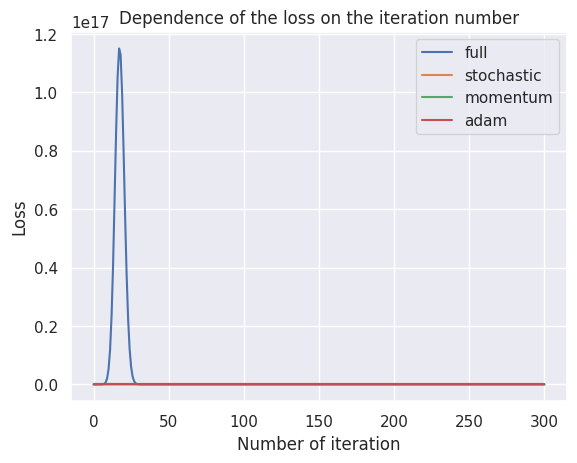

In [ ]:
np.random.seed(6)
descent_config = {
    'descent_name': '',
    'kwargs': {
        'dimension': X_train.shape[1],
        'lambda_': 0
    }
}

for descent_name, i in zip(['full', 'stochastic', 'momentum', 'adam'], range(4)):
    descent_config['descent_name'] = descent_name
    descent_config['kwargs']['lambda_'] = best_lambdas[i]
    lr = LinearRegression(descent_config=descent_config)
    lr.fit(X_train.values, y_train)
    iter_num = len(lr.loss_history)
    plt.plot(range(iter_num), lr.loss_history, label=descent_name)
plt.title('Dependence of the loss on the iteration number')
plt.xlabel('Number of iteration')
plt.ylabel('Loss')
plt.legend();

По значениям ошибок и R2 стохастический градиентный спуск показал себя хуже остальных, далее полный градиентный спуск, моментум и адам. Логично, что стохастический хуже, тк он обновляет параметры модели на основе лишь небольшого подмножества данных, из-за чего появляются осцилляции и шум. По идее он должен быстрее сходиться, но, возможно, здесь слишком маленький max_iter (тк только этот критерий остановки срабатывал). Полный град спуск более точный и стабильный, поэтому лучше. На графике виден скачок ошибки куда то в небеса, возможно, из-за масштаба целевой переменной и вида функции потерь. Моментум по сути модификация в данном случае полного градиентного спуска, который учитывает возможные колебания и сглаживает gd. Adam включает в себя моментум и использует адаптивные шаги для каждого признака, что улучшает сходимость, поэтому он показал себя лучше всего.


## Задание 6. Стохастический градиентный спуск и размер батча (1 балл)

В этом задании вам предстоит исследовать влияние размера батча на работу стохастического градиентного спуска.

* Сделайте по несколько запусков (например, k = 10) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерьте время в секундах и количество итераций до сходимости. Посчитайте среднее этих значений для каждого размера батча.
* Постройте график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Постройте график зависимости времени до сходимости от размера батча.

Посмотрите на получившиеся результаты. Какие выводы можно сделать про подбор размера батча для стохастического градиентного спуска?

In [ ]:
import time
from tqdm import tqdm
np.random.seed(6)
k = 6
batch_sizes = np.arange(5, 300, 30) # я уменьшила количество разных batch size потому что не успевала((

descent_config = {
    'descent_name': 'stochastic',
    'kwargs': {
        'dimension': X_train.shape[1],
        'lambda_': best_lambdas[1],
        'batch_size': 1
    }
}
time_batch = []
iter_count = []
for size in tqdm(batch_sizes):
    descent_config['kwargs']['batch_size'] = size
    lr = LinearRegression(descent_config=descent_config)
    time_size = []
    for i in range(k):
        start = time.time()
        lr.fit(X_train.values, y_train)
        time_spent = time.time() - start
        time_size.append(time_spent)
    time_size = np.mean(time_size)
    time_batch.append(time_size)
    iter_count.append(len(lr.loss_history))



100%|██████████| 10/10 [08:46<00:00, 52.69s/it]


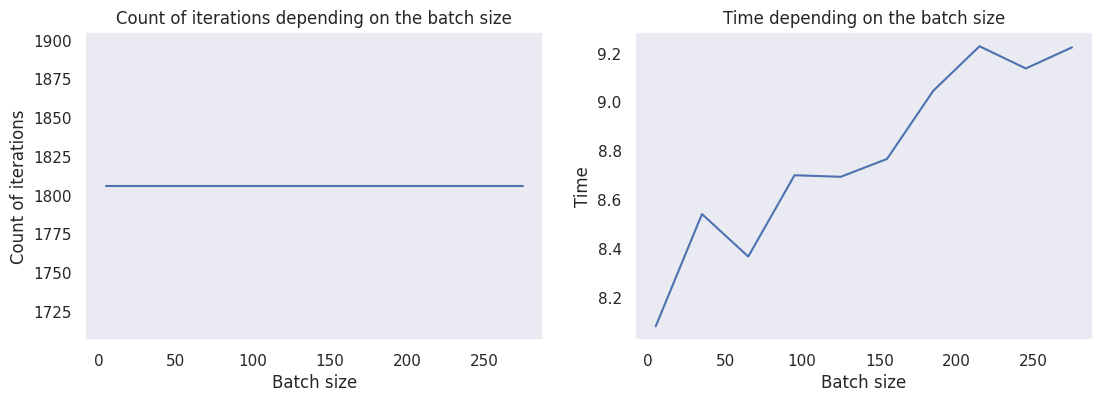

In [ ]:
fig, axs = plt.subplots(figsize=(13, 4), ncols=2)
sns.lineplot(x=batch_sizes, y=iter_count, ax=axs[0])
axs[0].set_xlabel('Batch size')
# axs[0].tick_params(axis='x', labelrotation=30)
axs[0].set_ylabel('Count of iterations')
axs[0].set_title('Count of iterations depending on the batch size')
axs[0].grid()

sns.lineplot(x=batch_sizes, y=time_batch, ax=axs[1])
axs[1].set_xlabel('Batch size')
axs[1].set_ylabel('Time')
axs[1].set_title('Time depending on the batch size')
axs[1].grid();

Чем выше размер батча, тем дольше сходимость по времени, так как мы берем большую часть выборки, и дольше считается градиент. Количество шагов: в данном сдучае не зависит, тк всегда доходит до max_iter